# 06 — Hyperparameter Tuning, Threshold Optimisation and Robustness

This notebook follows the underlying-only baseline modelling stage.

## Purpose

The baseline results suggested:

- weak and unstable directional prediction for RQ1;
- modest but positive magnitude-prediction ability for RQ2;
- useful ranking information for large moves in RQ3, but poor default-threshold recall.

This notebook investigates whether careful tuning improves those findings without simply searching for a higher score on a previously viewed test set.

## Critical test-set note

The baseline notebook has already displayed the original test results. Consequently, that test period can no longer be described as completely unseen.

The primary evidence in this notebook is therefore:

1. nested expanding-window cross-validation on the combined Train + Validation development period;
2. inner-fold hyperparameter selection;
3. outer-fold performance estimation;
4. fold-specific classification-threshold optimisation using only earlier observations.

The original Test split remains disabled by default and, if used later, must be described as a **secondary sensitivity check**, not a new confirmatory test.

## Research questions

### RQ1 — Direction

Can intraday features predict the direction of the final-hour SPX return?

Primary metric: outer-fold balanced accuracy.

### RQ2 — Magnitude

To what extent can intraday features predict the absolute final-hour movement?

Primary metric: outer-fold MAE in basis points.

### RQ3 — Large movements

Which features and model structures are useful for ranking and detecting unusually large final-hour movements?

Primary metric: outer-fold average precision.

Secondary metrics include balanced accuracy, recall, F1, ROC-AUC, R² and Spearman correlation where appropriate.

## 1. Environment and reproducibility settings

The default search budget is intentionally moderate. Increase `N_RANDOM_SEARCH_ITERATIONS` only after confirming that the notebook runs correctly.

The search is computationally heavier than the baseline notebook because every candidate model is tuned inside each outer time-series fold.

In [1]:
from pathlib import Path
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.special import expit
from scipy.stats import (
    loguniform,
    randint,
    spearmanr,
    uniform,
)

from sklearn.base import clone
from sklearn.ensemble import (
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import (
    ElasticNet,
    LogisticRegression,
    Ridge,
)
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    TimeSeriesSplit,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC, SVR

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42

# Moderate defaults. Increase only when the workflow is stable.
OUTER_SPLITS = 3
INNER_SPLITS = 3
N_RANDOM_SEARCH_ITERATIONS = 8

# The existing test set was already inspected in the baseline notebook.
RUN_EXISTING_TEST_AS_SECONDARY_CHECK = False

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")


def locate_project_root(start: Path) -> Path:
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "data" / "market.duckdb").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find data/market.duckdb. "
        "Place this notebook inside the Massive database project."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / "data"
DERIVED_ROOT = DATA_ROOT / "derived"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
TUNING_ROOT = OUTPUT_ROOT / "hyperparameter_tuning"
TABLE_ROOT = TUNING_ROOT / "tables"
FIGURE_ROOT = TUNING_ROOT / "figures"

TUNING_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Tuning output:", TUNING_ROOT)
print("Outer splits:", OUTER_SPLITS)
print("Inner splits:", INNER_SPLITS)
print("Random-search iterations:", N_RANDOM_SEARCH_ITERATIONS)


def save_figure(fig, filename: str) -> Path:
    path = FIGURE_ROOT / filename
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    return path

Project root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation
Tuning output: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning
Outer splits: 3
Inner splits: 3
Random-search iterations: 8


## 2. Load the strict and relaxed datasets

Only Train and Validation rows are used for primary nested tuning. Test rows are loaded so that date boundaries can be audited, but they are not used in search or model selection.

In [2]:
STRICT_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_strict_split.parquet"
)

RELAXED_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_relaxed_split.parquet"
)

if not STRICT_PATH.exists() or not RELAXED_PATH.exists():
    raise FileNotFoundError(
        "Run 04_build_strict_and_relaxed_datasets.ipynb first."
    )


def load_variant(path: Path, variant_name: str) -> pd.DataFrame:
    frame = pd.read_parquet(path)
    frame["session_date"] = pd.to_datetime(frame["session_date"])
    frame = frame.sort_values("session_date").reset_index(drop=True)

    required = {
        "session_date",
        "data_split",
        "final_hour_return",
        "target_up",
        "spx_at_1500",
        "atr_open_to_1500",
    }

    missing = required.difference(frame.columns)

    if missing:
        raise ValueError(
            f"{variant_name} dataset is missing: {sorted(missing)}"
        )

    frame["atr_pct_open_to_1500"] = (
        frame["atr_open_to_1500"]
        / frame["spx_at_1500"]
    )

    frame["target_magnitude_bps"] = (
        frame["final_hour_return"].abs() * 10_000
    )

    return frame


strict_data = load_variant(STRICT_PATH, "Strict")
relaxed_data = load_variant(RELAXED_PATH, "Relaxed")

datasets = {
    "Strict": strict_data,
    "Relaxed": relaxed_data,
}

coverage_rows = []

for variant, frame in datasets.items():
    for split_name in ["Train", "Validation", "Test"]:
        subset = frame[frame["data_split"].eq(split_name)]

        coverage_rows.append(
            {
                "dataset_variant": variant,
                "data_split": split_name,
                "sessions": len(subset),
                "first_date": subset["session_date"].min(),
                "last_date": subset["session_date"].max(),
                "up_pct": subset["target_up"].mean() * 100,
            }
        )

coverage = pd.DataFrame(coverage_rows)
display(coverage)

for variant, frame in datasets.items():
    development = frame[
        frame["data_split"].isin(["Train", "Validation"])
    ].sort_values("session_date")

    test = frame[
        frame["data_split"].eq("Test")
    ].sort_values("session_date")

    assert development["session_date"].max() < test["session_date"].min()

print("Development and test date ordering verified.")

,dataset_variant,data_split,sessions,first_date,last_date,up_pct
0,Strict,Train,303,2024-07-18,2025-12-03,48.514851
1,Strict,Validation,65,2025-12-04,2026-03-20,44.615385
2,Strict,Test,66,2026-03-23,2026-07-17,60.606061
3,Relaxed,Train,334,2024-07-18,2025-12-03,47.305389
4,Relaxed,Validation,71,2025-12-04,2026-03-20,45.070423
5,Relaxed,Test,81,2026-03-23,2026-07-17,61.728395


Development and test date ordering verified.


## 3. Feature sets and targets

Two feature sets are compared.

### Full set

The 22 underlying features retained in the baseline notebook.

### Reduced set

A more compact set that removes some overlapping realised-volatility, return-window and volume variables. This tests whether reducing collinearity improves temporal stability.

The large-movement threshold remains fixed using the 75th percentile of the strict original training period, preserving comparability with the baseline analysis.

In [3]:
FULL_FEATURES = [
    "ret_open_to_1500",
    "ret_last_15m",
    "ret_last_30m",
    "ret_last_60m",
    "momentum_accel_60m_vs_prior",
    "vix_level_1500",
    "vix_ret_last_15m",
    "vix_ret_last_30m",
    "vix_ret_last_60m",
    "realized_vol_30m",
    "realized_vol_60m",
    "realized_vol_120m",
    "rv_open_to_1500",
    "spy_volume_last_30m",
    "spy_volume_last_60m",
    "spy_cum_volume_to_1500",
    "spy_volume_accel_60m_vs_avg",
    "spy_dist_from_vwap_pct",
    "position_in_day_range",
    "dist_from_day_high_pct",
    "dist_from_day_low_pct",
    "atr_pct_open_to_1500",
]

REDUCED_FEATURES = [
    "ret_open_to_1500",
    "ret_last_15m",
    "ret_last_60m",
    "momentum_accel_60m_vs_prior",
    "vix_level_1500",
    "vix_ret_last_15m",
    "vix_ret_last_60m",
    "realized_vol_30m",
    "realized_vol_120m",
    "rv_open_to_1500",
    "spy_volume_last_60m",
    "spy_volume_accel_60m_vs_avg",
    "spy_dist_from_vwap_pct",
    "position_in_day_range",
    "atr_pct_open_to_1500",
]

FEATURE_SETS = {
    "Full": FULL_FEATURES,
    "Reduced": REDUCED_FEATURES,
}

LARGE_MOVE_QUANTILE = 0.75

strict_original_train = strict_data[
    strict_data["data_split"].eq("Train")
]

LARGE_MOVE_THRESHOLD_RETURN = float(
    strict_original_train["final_hour_return"]
    .abs()
    .quantile(LARGE_MOVE_QUANTILE)
)

LARGE_MOVE_THRESHOLD_BPS = (
    LARGE_MOVE_THRESHOLD_RETURN * 10_000
)

for variant, frame in datasets.items():
    frame["target_large_move"] = (
        frame["final_hour_return"].abs()
        >= LARGE_MOVE_THRESHOLD_RETURN
    ).astype("int8")

    for feature_set_name, features in FEATURE_SETS.items():
        missing = set(features).difference(frame.columns)

        if missing:
            raise ValueError(
                f"{variant}/{feature_set_name} missing: {sorted(missing)}"
            )

        frame[features] = frame[features].replace(
            [np.inf, -np.inf],
            np.nan,
        )

print(
    f"Large-movement threshold: "
    f"{LARGE_MOVE_THRESHOLD_BPS:.3f} basis points"
)

feature_set_summary = pd.DataFrame(
    [
        {
            "feature_set": name,
            "feature_count": len(features),
            "features": ", ".join(features),
        }
        for name, features in FEATURE_SETS.items()
    ]
)

display(feature_set_summary)

Large-movement threshold: 27.504 basis points


,feature_set,feature_count,features
0,Full,22,"ret_open_to_1500, ret_last_15m, ret_last_30m, ..."
1,Reduced,15,"ret_open_to_1500, ret_last_15m, ret_last_60m, ..."


## 4. Tuned model families and search spaces

The search focuses on diverse model families rather than tuning every baseline algorithm.

### Classification

- elastic-net logistic regression;
- Extra Trees;
- histogram gradient boosting;
- RBF support vector classifier.

### Regression

- ridge regression;
- elastic net;
- Extra Trees;
- histogram gradient boosting;
- RBF support vector regression.

The search spaces are deliberately bounded to reduce overfitting and computational cost.

In [4]:
def scaled_pipeline(estimator) -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
            ("model", estimator),
        ]
    )


def unscaled_pipeline(estimator) -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("model", estimator),
        ]
    )


CLASSIFICATION_SEARCH_SPACES = {
    "Logistic ElasticNet": {
        "estimator": scaled_pipeline(
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                class_weight="balanced",
                max_iter=5_000,
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__C": loguniform(1e-3, 100),
            "model__l1_ratio": uniform(0, 1),
        },
    },
    "Extra Trees": {
        "estimator": unscaled_pipeline(
            ExtraTreesClassifier(
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__n_estimators": randint(200, 800),
            "model__max_depth": [None, 3, 5, 8, 12],
            "model__min_samples_leaf": randint(2, 16),
            "model__min_samples_split": randint(2, 20),
            "model__max_features": ["sqrt", "log2", 0.5, 0.8],
            "model__class_weight": [
                "balanced",
                "balanced_subsample",
            ],
            "model__bootstrap": [False, True],
        },
    },
    "Histogram Gradient Boosting": {
        "estimator": unscaled_pipeline(
            HistGradientBoostingClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__learning_rate": loguniform(0.01, 0.20),
            "model__max_iter": randint(100, 450),
            "model__max_leaf_nodes": randint(5, 32),
            "model__min_samples_leaf": randint(8, 32),
            "model__l2_regularization": loguniform(1e-3, 20),
            "model__max_bins": [32, 64, 128, 255],
        },
    },
    "RBF SVC": {
        "estimator": scaled_pipeline(
            SVC(
                kernel="rbf",
                class_weight="balanced",
                probability=False,
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__C": loguniform(1e-2, 100),
            "model__gamma": loguniform(1e-4, 1),
        },
    },
}


REGRESSION_SEARCH_SPACES = {
    "Ridge Regression": {
        "estimator": scaled_pipeline(
            Ridge()
        ),
        "parameters": {
            "model__alpha": loguniform(1e-3, 1_000),
        },
    },
    "Elastic Net": {
        "estimator": scaled_pipeline(
            ElasticNet(
                max_iter=20_000,
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__alpha": loguniform(1e-4, 10),
            "model__l1_ratio": uniform(0, 1),
        },
    },
    "Extra Trees": {
        "estimator": unscaled_pipeline(
            ExtraTreesRegressor(
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__n_estimators": randint(200, 800),
            "model__max_depth": [None, 3, 5, 8, 12],
            "model__min_samples_leaf": randint(2, 16),
            "model__min_samples_split": randint(2, 20),
            "model__max_features": ["sqrt", "log2", 0.5, 0.8],
            "model__bootstrap": [False, True],
        },
    },
    "Histogram Gradient Boosting": {
        "estimator": unscaled_pipeline(
            HistGradientBoostingRegressor(
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__loss": ["absolute_error", "squared_error"],
            "model__learning_rate": loguniform(0.01, 0.20),
            "model__max_iter": randint(100, 450),
            "model__max_leaf_nodes": randint(5, 32),
            "model__min_samples_leaf": randint(8, 32),
            "model__l2_regularization": loguniform(1e-3, 20),
            "model__max_bins": [32, 64, 128, 255],
        },
    },
    "RBF SVR": {
        "estimator": scaled_pipeline(
            SVR(kernel="rbf")
        ),
        "parameters": {
            "model__C": loguniform(1e-2, 100),
            "model__epsilon": loguniform(0.05, 8),
            "model__gamma": loguniform(1e-4, 1),
        },
    },
}

print("Classification families:", len(CLASSIFICATION_SEARCH_SPACES))
print("Regression families:", len(REGRESSION_SEARCH_SPACES))

Classification families: 4
Regression families: 5


## 5. Evaluation and threshold functions

Classification thresholds are selected inside each outer fold.

For every outer training block:

1. the hyperparameters are selected using inner expanding-window search;
2. the selected estimator generates inner time-series out-of-fold scores;
3. a threshold is selected using only those inner historical scores;
4. the estimator and threshold are evaluated on the later outer fold.

RQ1 thresholds maximise balanced accuracy.

RQ3 thresholds maximise F1 to address the very low recall observed at the default threshold in the baseline model.

In [5]:
def model_scores(estimator, X: pd.DataFrame) -> np.ndarray:
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]

    if hasattr(estimator, "decision_function"):
        return np.asarray(estimator.decision_function(X))

    return np.asarray(estimator.predict(X), dtype=float)


def safe_auc(y_true, scores) -> float:
    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(roc_auc_score(y_true, scores))


def safe_average_precision(y_true, scores) -> float:
    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(average_precision_score(y_true, scores))


def classification_metric_bundle(
    y_true,
    predictions,
    scores,
) -> dict:
    return {
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            predictions,
        ),
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "mcc": matthews_corrcoef(
            y_true,
            predictions,
        ),
        "roc_auc": safe_auc(y_true, scores),
        "average_precision": safe_average_precision(
            y_true,
            scores,
        ),
    }


def regression_metric_bundle(
    y_true,
    predictions,
) -> dict:
    rank_correlation = spearmanr(
        y_true,
        predictions,
        nan_policy="omit",
    ).statistic

    return {
        "mae_bps": mean_absolute_error(
            y_true,
            predictions,
        ),
        "rmse_bps": math.sqrt(
            mean_squared_error(
                y_true,
                predictions,
            )
        ),
        "r2": r2_score(
            y_true,
            predictions,
        ),
        "spearman": rank_correlation,
    }


def inner_time_series_scores(
    estimator,
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int,
):
    splitter = TimeSeriesSplit(n_splits=n_splits)

    true_values = []
    scores = []

    for train_index, validation_index in splitter.split(X):
        fold_estimator = clone(estimator)

        fold_estimator.fit(
            X.iloc[train_index],
            y.iloc[train_index],
        )

        fold_scores = model_scores(
            fold_estimator,
            X.iloc[validation_index],
        )

        true_values.extend(
            y.iloc[validation_index].to_numpy()
        )

        scores.extend(fold_scores)

    return (
        np.asarray(true_values, dtype=int),
        np.asarray(scores, dtype=float),
    )


def select_threshold(
    y_true,
    scores,
    objective: str,
):
    if len(np.unique(scores)) < 2:
        return float(scores[0]), np.nan

    quantiles = np.linspace(0.02, 0.98, 97)
    candidates = np.unique(
        np.quantile(scores, quantiles)
    )

    # Include standard probability and decision-function cutoffs.
    candidates = np.unique(
        np.concatenate(
            [
                candidates,
                np.array([0.0, 0.5]),
            ]
        )
    )

    rows = []

    for threshold in candidates:
        predictions = (scores >= threshold).astype(int)

        if objective == "balanced_accuracy":
            value = balanced_accuracy_score(
                y_true,
                predictions,
            )
        elif objective == "f1":
            value = f1_score(
                y_true,
                predictions,
                zero_division=0,
            )
        else:
            raise ValueError(
                f"Unsupported threshold objective: {objective}"
            )

        rows.append(
            {
                "threshold": threshold,
                "objective_value": value,
            }
        )

    threshold_table = pd.DataFrame(rows).sort_values(
        ["objective_value", "threshold"],
        ascending=[False, True],
    )

    best = threshold_table.iloc[0]

    return (
        float(best["threshold"]),
        float(best["objective_value"]),
    )


def development_frame(frame: pd.DataFrame) -> pd.DataFrame:
    return (
        frame[
            frame["data_split"].isin(
                ["Train", "Validation"]
            )
        ]
        .sort_values("session_date")
        .reset_index(drop=True)
    )

## 6. Nested classification tuning

This function is used for both RQ1 and RQ3.

The outer-fold metrics represent the main generalisation estimate. The search score itself is not treated as final performance because it is used to choose hyperparameters.

In [6]:
def nested_classification_search(
    frame: pd.DataFrame,
    variant_name: str,
    feature_set_name: str,
    features: list[str],
    target_column: str,
    task_name: str,
    search_scoring: str,
    threshold_objective: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    development = development_frame(frame)

    X = development[features]
    y = development[target_column].astype(int)

    outer_splitter = TimeSeriesSplit(
        n_splits=OUTER_SPLITS
    )

    summary_rows = []
    fold_rows = []

    for model_name, specification in (
        CLASSIFICATION_SEARCH_SPACES.items()
    ):
        fold_metrics = []

        for outer_fold, (
            outer_train_index,
            outer_test_index,
        ) in enumerate(
            outer_splitter.split(X),
            start=1,
        ):
            X_outer_train = X.iloc[outer_train_index]
            y_outer_train = y.iloc[outer_train_index]
            X_outer_test = X.iloc[outer_test_index]
            y_outer_test = y.iloc[outer_test_index]

            inner_splitter = TimeSeriesSplit(
                n_splits=INNER_SPLITS
            )

            search = RandomizedSearchCV(
                estimator=clone(
                    specification["estimator"]
                ),
                param_distributions=(
                    specification["parameters"]
                ),
                n_iter=N_RANDOM_SEARCH_ITERATIONS,
                scoring=search_scoring,
                cv=inner_splitter,
                refit=True,
                random_state=(
                    RANDOM_STATE + outer_fold
                ),
                n_jobs=-1,
                return_train_score=False,
            )

            search.fit(
                X_outer_train,
                y_outer_train,
            )

            best_estimator = search.best_estimator_

            inner_y, inner_scores = inner_time_series_scores(
                best_estimator,
                X_outer_train.reset_index(drop=True),
                y_outer_train.reset_index(drop=True),
                n_splits=INNER_SPLITS,
            )

            threshold, threshold_score = select_threshold(
                inner_y,
                inner_scores,
                objective=threshold_objective,
            )

            outer_scores = model_scores(
                best_estimator,
                X_outer_test,
            )

            outer_predictions = (
                outer_scores >= threshold
            ).astype(int)

            metrics = classification_metric_bundle(
                y_outer_test,
                outer_predictions,
                outer_scores,
            )

            metrics.update(
                {
                    "outer_fold": outer_fold,
                    "outer_train_start": (
                        development.iloc[
                            outer_train_index
                        ]["session_date"].min()
                    ),
                    "outer_train_end": (
                        development.iloc[
                            outer_train_index
                        ]["session_date"].max()
                    ),
                    "outer_test_start": (
                        development.iloc[
                            outer_test_index
                        ]["session_date"].min()
                    ),
                    "outer_test_end": (
                        development.iloc[
                            outer_test_index
                        ]["session_date"].max()
                    ),
                    "threshold": threshold,
                    "inner_threshold_objective": (
                        threshold_score
                    ),
                    "inner_best_search_score": (
                        search.best_score_
                    ),
                    "best_parameters": json.dumps(
                        search.best_params_,
                        sort_keys=True,
                        default=str,
                    ),
                }
            )

            fold_metrics.append(metrics)

            fold_rows.append(
                {
                    "task": task_name,
                    "dataset_variant": variant_name,
                    "feature_set": feature_set_name,
                    "model": model_name,
                    **metrics,
                }
            )

        fold_frame = pd.DataFrame(fold_metrics)

        summary_rows.append(
            {
                "task": task_name,
                "dataset_variant": variant_name,
                "feature_set": feature_set_name,
                "model": model_name,
                "outer_balanced_accuracy_mean": (
                    fold_frame[
                        "balanced_accuracy"
                    ].mean()
                ),
                "outer_balanced_accuracy_std": (
                    fold_frame[
                        "balanced_accuracy"
                    ].std()
                ),
                "outer_accuracy_mean": (
                    fold_frame["accuracy"].mean()
                ),
                "outer_f1_mean": (
                    fold_frame["f1"].mean()
                ),
                "outer_recall_mean": (
                    fold_frame["recall"].mean()
                ),
                "outer_mcc_mean": (
                    fold_frame["mcc"].mean()
                ),
                "outer_roc_auc_mean": (
                    fold_frame["roc_auc"].mean()
                ),
                "outer_average_precision_mean": (
                    fold_frame[
                        "average_precision"
                    ].mean()
                ),
                "outer_threshold_mean": (
                    fold_frame["threshold"].mean()
                ),
                "outer_threshold_std": (
                    fold_frame["threshold"].std()
                ),
            }
        )

    return (
        pd.DataFrame(summary_rows),
        pd.DataFrame(fold_rows),
    )

## 7. Nested regression tuning

RQ2 uses MAE as the search and outer-fold selection metric. R² and Spearman correlation are retained to distinguish small absolute-error improvements from genuine ranking or explanatory ability.

In [7]:
def nested_regression_search(
    frame: pd.DataFrame,
    variant_name: str,
    feature_set_name: str,
    features: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    development = development_frame(frame)

    X = development[features]
    y = development["target_magnitude_bps"]

    outer_splitter = TimeSeriesSplit(
        n_splits=OUTER_SPLITS
    )

    summary_rows = []
    fold_rows = []

    for model_name, specification in (
        REGRESSION_SEARCH_SPACES.items()
    ):
        fold_metrics = []

        for outer_fold, (
            outer_train_index,
            outer_test_index,
        ) in enumerate(
            outer_splitter.split(X),
            start=1,
        ):
            X_outer_train = X.iloc[outer_train_index]
            y_outer_train = y.iloc[outer_train_index]
            X_outer_test = X.iloc[outer_test_index]
            y_outer_test = y.iloc[outer_test_index]

            inner_splitter = TimeSeriesSplit(
                n_splits=INNER_SPLITS
            )

            search = RandomizedSearchCV(
                estimator=clone(
                    specification["estimator"]
                ),
                param_distributions=(
                    specification["parameters"]
                ),
                n_iter=N_RANDOM_SEARCH_ITERATIONS,
                scoring="neg_mean_absolute_error",
                cv=inner_splitter,
                refit=True,
                random_state=(
                    RANDOM_STATE + outer_fold
                ),
                n_jobs=-1,
                return_train_score=False,
            )

            search.fit(
                X_outer_train,
                y_outer_train,
            )

            predictions = search.best_estimator_.predict(
                X_outer_test
            )

            metrics = regression_metric_bundle(
                y_outer_test,
                predictions,
            )

            metrics.update(
                {
                    "outer_fold": outer_fold,
                    "outer_train_start": (
                        development.iloc[
                            outer_train_index
                        ]["session_date"].min()
                    ),
                    "outer_train_end": (
                        development.iloc[
                            outer_train_index
                        ]["session_date"].max()
                    ),
                    "outer_test_start": (
                        development.iloc[
                            outer_test_index
                        ]["session_date"].min()
                    ),
                    "outer_test_end": (
                        development.iloc[
                            outer_test_index
                        ]["session_date"].max()
                    ),
                    "inner_best_search_score": (
                        search.best_score_
                    ),
                    "best_parameters": json.dumps(
                        search.best_params_,
                        sort_keys=True,
                        default=str,
                    ),
                }
            )

            fold_metrics.append(metrics)

            fold_rows.append(
                {
                    "task": "RQ2 Magnitude",
                    "dataset_variant": variant_name,
                    "feature_set": feature_set_name,
                    "model": model_name,
                    **metrics,
                }
            )

        fold_frame = pd.DataFrame(fold_metrics)

        summary_rows.append(
            {
                "task": "RQ2 Magnitude",
                "dataset_variant": variant_name,
                "feature_set": feature_set_name,
                "model": model_name,
                "outer_mae_bps_mean": (
                    fold_frame["mae_bps"].mean()
                ),
                "outer_mae_bps_std": (
                    fold_frame["mae_bps"].std()
                ),
                "outer_rmse_bps_mean": (
                    fold_frame["rmse_bps"].mean()
                ),
                "outer_r2_mean": (
                    fold_frame["r2"].mean()
                ),
                "outer_spearman_mean": (
                    fold_frame["spearman"].mean()
                ),
            }
        )

    return (
        pd.DataFrame(summary_rows),
        pd.DataFrame(fold_rows),
    )

# 8. Run RQ1 tuning

This is the most difficult research question. A tuned model should not be considered successful merely because it achieves the highest score among the candidates.

A convincing result requires:

- mean outer balanced accuracy materially above 0.50;
- limited fold-to-fold variation;
- improvement over the simple 60-minute mean-reversion rule;
- no collapse when moving from strict to relaxed data or from full to reduced features.

In [8]:
rq1_summary_frames = []
rq1_fold_frames = []

for variant_name, frame in datasets.items():
    for feature_set_name, features in FEATURE_SETS.items():
        summary, folds = nested_classification_search(
            frame=frame,
            variant_name=variant_name,
            feature_set_name=feature_set_name,
            features=features,
            target_column="target_up",
            task_name="RQ1 Direction",
            search_scoring="balanced_accuracy",
            threshold_objective="balanced_accuracy",
        )

        rq1_summary_frames.append(summary)
        rq1_fold_frames.append(folds)

rq1_tuning_summary = pd.concat(
    rq1_summary_frames,
    ignore_index=True,
)

rq1_tuning_folds = pd.concat(
    rq1_fold_frames,
    ignore_index=True,
)

rq1_tuning_summary = rq1_tuning_summary.sort_values(
    [
        "outer_balanced_accuracy_mean",
        "outer_balanced_accuracy_std",
    ],
    ascending=[False, True],
).reset_index(drop=True)

display(rq1_tuning_summary)

RQ1_SUMMARY_PATH = (
    TABLE_ROOT
    / "rq1_nested_tuning_summary.csv"
)

RQ1_FOLDS_PATH = (
    TABLE_ROOT
    / "rq1_nested_tuning_outer_folds.csv"
)

rq1_tuning_summary.to_csv(
    RQ1_SUMMARY_PATH,
    index=False,
)

rq1_tuning_folds.to_csv(
    RQ1_FOLDS_PATH,
    index=False,
)

print("Saved:", RQ1_SUMMARY_PATH)
print("Saved:", RQ1_FOLDS_PATH)

,task,dataset_variant,feature_set,model,outer_balanced_accuracy_mean,outer_balanced_accuracy_std,outer_accuracy_mean,outer_f1_mean,outer_recall_mean,outer_mcc_mean,outer_roc_auc_mean,outer_average_precision_mean,outer_threshold_mean,outer_threshold_std
0,RQ1 Direction,Relaxed,Full,Histogram Gradient Boosting,0.543691,0.047583,0.518152,0.520503,0.622105,0.083023,0.555345,0.528443,0.462897,0.097238
1,RQ1 Direction,Strict,Full,Histogram Gradient Boosting,0.537485,0.032072,0.547101,0.488652,0.484059,0.074722,0.548061,0.552690,0.503818,0.038821
2,RQ1 Direction,Strict,Reduced,Histogram Gradient Boosting,0.534431,0.050846,0.532609,0.532019,0.588335,0.067563,0.531804,0.518956,0.471271,0.035187
3,RQ1 Direction,Relaxed,Reduced,Extra Trees,0.530858,0.063429,0.528053,0.484584,0.522521,0.073876,0.553179,0.535140,0.502882,0.008848
4,RQ1 Direction,Relaxed,Full,Extra Trees,0.519432,0.046740,0.501650,0.508353,0.608103,0.033306,0.545706,0.528029,0.493567,0.024902
5,RQ1 Direction,Strict,Reduced,RBF SVC,0.507142,0.006263,0.489130,0.570858,0.757608,0.014710,0.521646,0.489435,-0.369453,0.567105
6,RQ1 Direction,Relaxed,Reduced,RBF SVC,0.504834,0.027148,0.541254,0.357587,0.319549,0.007973,0.517247,0.523793,0.398381,0.412869
7,RQ1 Direction,Relaxed,Reduced,Histogram Gradient Boosting,0.504732,0.020016,0.495050,0.477300,0.518550,0.009132,0.530536,0.510543,0.446345,0.066545
8,RQ1 Direction,Relaxed,Full,RBF SVC,0.504065,0.007041,0.570957,0.248131,0.341463,0.040324,0.489129,0.485278,0.572557,1.348069
9,RQ1 Direction,Relaxed,Reduced,Logistic ElasticNet,0.503797,0.074189,0.495050,0.534785,0.669044,0.013642,0.524167,0.496884,0.497585,0.006134


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\tables\rq1_nested_tuning_summary.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\tables\rq1_nested_tuning_outer_folds.csv


# 9. Run RQ2 tuning

In [9]:
rq2_summary_frames = []
rq2_fold_frames = []

for variant_name, frame in datasets.items():
    for feature_set_name, features in FEATURE_SETS.items():
        summary, folds = nested_regression_search(
            frame=frame,
            variant_name=variant_name,
            feature_set_name=feature_set_name,
            features=features,
        )

        rq2_summary_frames.append(summary)
        rq2_fold_frames.append(folds)

rq2_tuning_summary = pd.concat(
    rq2_summary_frames,
    ignore_index=True,
)

rq2_tuning_folds = pd.concat(
    rq2_fold_frames,
    ignore_index=True,
)

rq2_tuning_summary = rq2_tuning_summary.sort_values(
    [
        "outer_mae_bps_mean",
        "outer_mae_bps_std",
    ],
    ascending=[True, True],
).reset_index(drop=True)

display(rq2_tuning_summary)

RQ2_SUMMARY_PATH = (
    TABLE_ROOT
    / "rq2_nested_tuning_summary.csv"
)

RQ2_FOLDS_PATH = (
    TABLE_ROOT
    / "rq2_nested_tuning_outer_folds.csv"
)

rq2_tuning_summary.to_csv(
    RQ2_SUMMARY_PATH,
    index=False,
)

rq2_tuning_folds.to_csv(
    RQ2_FOLDS_PATH,
    index=False,
)

print("Saved:", RQ2_SUMMARY_PATH)
print("Saved:", RQ2_FOLDS_PATH)

,task,dataset_variant,feature_set,model,outer_mae_bps_mean,outer_mae_bps_std,outer_rmse_bps_mean,outer_r2_mean,outer_spearman_mean
0,RQ2 Magnitude,Relaxed,Reduced,Extra Trees,13.766881,4.664372,20.979558,0.062219,0.444356
1,RQ2 Magnitude,Relaxed,Full,Histogram Gradient Boosting,14.378387,6.349418,22.696112,-0.025626,0.388809
2,RQ2 Magnitude,Relaxed,Full,Extra Trees,14.382633,3.989185,21.539133,-0.046251,0.435807
3,RQ2 Magnitude,Strict,Reduced,Extra Trees,14.822870,4.059481,22.551816,-0.038727,0.421636
4,RQ2 Magnitude,Strict,Reduced,Histogram Gradient Boosting,14.852830,6.761435,23.544747,-0.006677,0.377136
5,RQ2 Magnitude,Relaxed,Full,Elastic Net,15.004542,3.771261,21.474800,-0.164959,0.408550
6,RQ2 Magnitude,Relaxed,Reduced,RBF SVR,15.151166,7.717182,23.528053,-0.077435,0.333603
7,RQ2 Magnitude,Relaxed,Full,RBF SVR,15.241347,7.572487,23.494083,-0.086619,0.346643
8,RQ2 Magnitude,Strict,Reduced,RBF SVR,15.244466,6.604379,23.739869,-0.028483,0.353284
9,RQ2 Magnitude,Relaxed,Reduced,Histogram Gradient Boosting,15.277644,5.685993,23.986925,-0.256439,0.369570


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\tables\rq2_nested_tuning_summary.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\tables\rq2_nested_tuning_outer_folds.csv


# 10. Run RQ3 tuning

Average precision is the primary selection metric because it evaluates large-move ranking without imposing a fixed threshold.

The fold-specific F1 threshold is reported separately to determine whether the poor large-move recall in the baseline was mainly a threshold problem.

In [10]:
rq3_summary_frames = []
rq3_fold_frames = []

for variant_name, frame in datasets.items():
    for feature_set_name, features in FEATURE_SETS.items():
        summary, folds = nested_classification_search(
            frame=frame,
            variant_name=variant_name,
            feature_set_name=feature_set_name,
            features=features,
            target_column="target_large_move",
            task_name="RQ3 Large Movement",
            search_scoring="average_precision",
            threshold_objective="f1",
        )

        rq3_summary_frames.append(summary)
        rq3_fold_frames.append(folds)

rq3_tuning_summary = pd.concat(
    rq3_summary_frames,
    ignore_index=True,
)

rq3_tuning_folds = pd.concat(
    rq3_fold_frames,
    ignore_index=True,
)

rq3_tuning_summary = rq3_tuning_summary.sort_values(
    [
        "outer_average_precision_mean",
        "outer_recall_mean",
        "outer_f1_mean",
    ],
    ascending=[False, False, False],
).reset_index(drop=True)

display(rq3_tuning_summary)

RQ3_SUMMARY_PATH = (
    TABLE_ROOT
    / "rq3_nested_tuning_summary.csv"
)

RQ3_FOLDS_PATH = (
    TABLE_ROOT
    / "rq3_nested_tuning_outer_folds.csv"
)

rq3_tuning_summary.to_csv(
    RQ3_SUMMARY_PATH,
    index=False,
)

rq3_tuning_folds.to_csv(
    RQ3_FOLDS_PATH,
    index=False,
)

print("Saved:", RQ3_SUMMARY_PATH)
print("Saved:", RQ3_FOLDS_PATH)

,task,dataset_variant,feature_set,model,outer_balanced_accuracy_mean,outer_balanced_accuracy_std,outer_accuracy_mean,outer_f1_mean,outer_recall_mean,outer_mcc_mean,outer_roc_auc_mean,outer_average_precision_mean,outer_threshold_mean,outer_threshold_std
0,RQ3 Large Movement,Strict,Full,RBF SVC,0.696687,0.057728,0.652174,0.526013,0.788883,0.330867,0.735996,0.499413,-0.171467,0.315041
1,RQ3 Large Movement,Relaxed,Full,Extra Trees,0.739199,0.072471,0.683168,0.532095,0.846377,0.375085,0.770240,0.490105,0.476146,0.042635
2,RQ3 Large Movement,Relaxed,Full,Logistic ElasticNet,0.695389,0.056392,0.726073,0.527866,0.691143,0.337799,0.745500,0.487274,0.531137,0.036112
3,RQ3 Large Movement,Strict,Full,Logistic ElasticNet,0.659583,0.083316,0.692029,0.507590,0.661177,0.295909,0.711590,0.485002,0.505509,0.021006
4,RQ3 Large Movement,Strict,Reduced,Extra Trees,0.673934,0.058251,0.728261,0.520248,0.645367,0.323456,0.745450,0.484753,0.508173,0.007328
5,RQ3 Large Movement,Strict,Reduced,RBF SVC,0.585971,0.074581,0.688406,0.304968,0.404040,0.146119,0.725215,0.479418,0.116437,0.479249
6,RQ3 Large Movement,Strict,Full,Extra Trees,0.659858,0.069125,0.572464,0.496032,0.879980,0.272641,0.744193,0.478909,0.394770,0.061750
7,RQ3 Large Movement,Relaxed,Full,RBF SVC,0.649916,0.027058,0.706271,0.478205,0.609662,0.266311,0.755894,0.476808,0.027595,0.025515
8,RQ3 Large Movement,Relaxed,Reduced,Logistic ElasticNet,0.652772,0.088066,0.660066,0.489661,0.727858,0.252727,0.723943,0.468531,0.358191,0.217383
9,RQ3 Large Movement,Strict,Reduced,Logistic ElasticNet,0.604765,0.105648,0.532609,0.463888,0.736150,0.199807,0.683718,0.463474,0.431566,0.073422


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\tables\rq3_nested_tuning_summary.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\tables\rq3_nested_tuning_outer_folds.csv


## 11. Ranking and stability charts

The error bars show one standard deviation across outer temporal folds. A model with a slightly lower mean but much lower variability may be preferable for the dissertation.

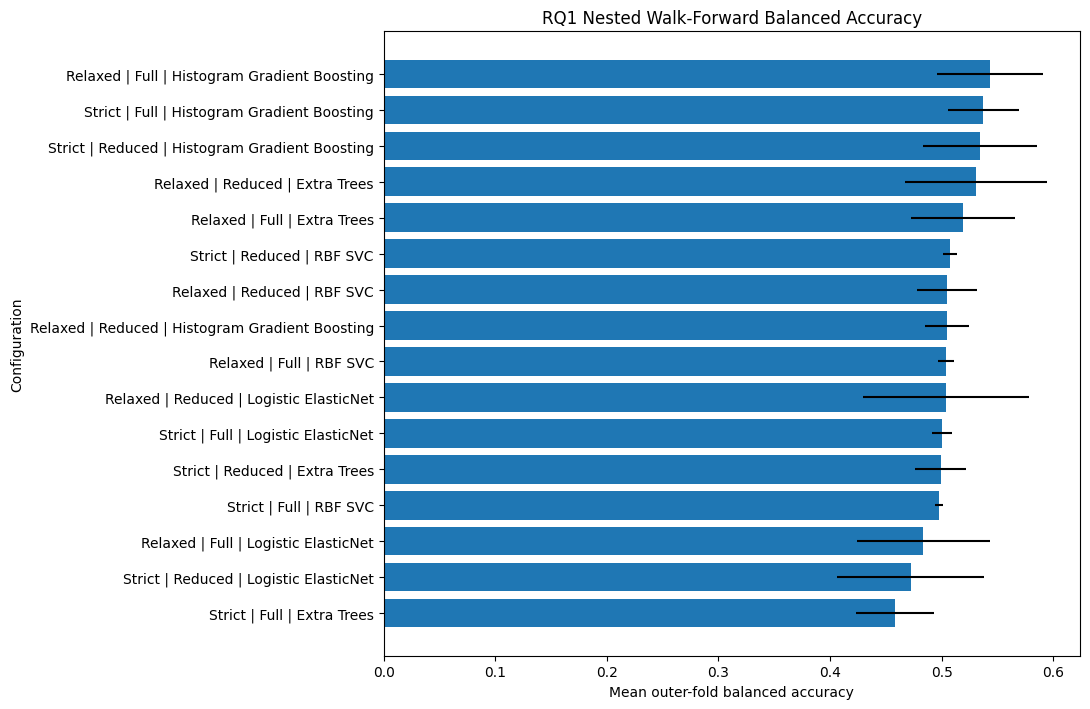

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\figures\rq1_nested_balanced_accuracy.png


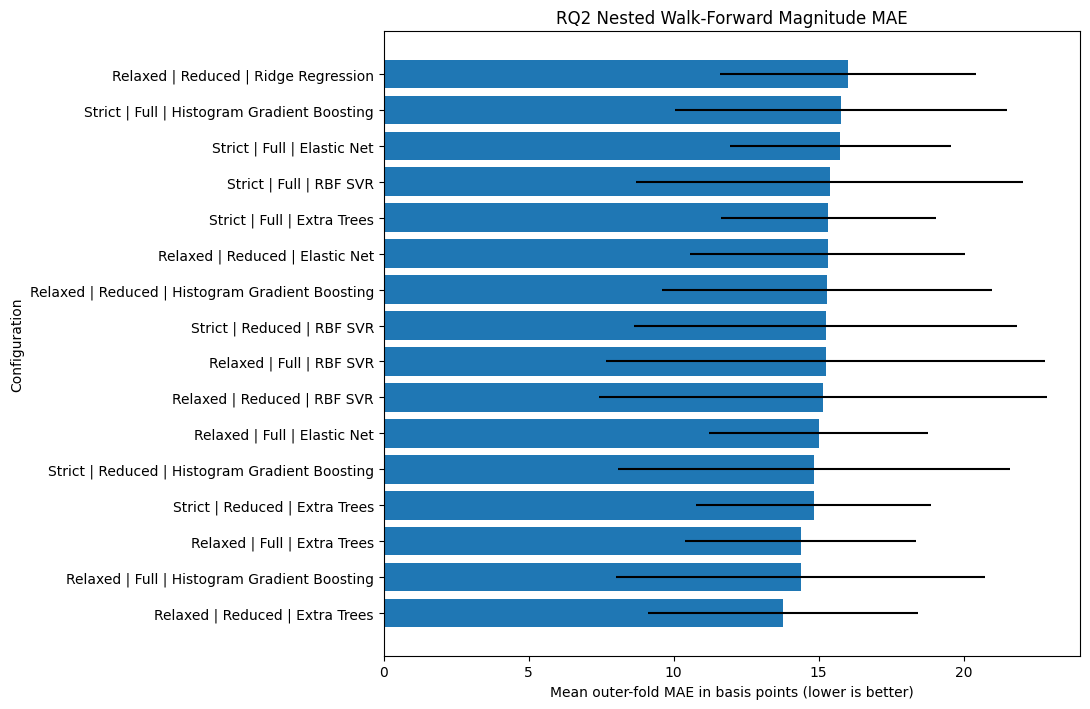

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\figures\rq2_nested_mae.png


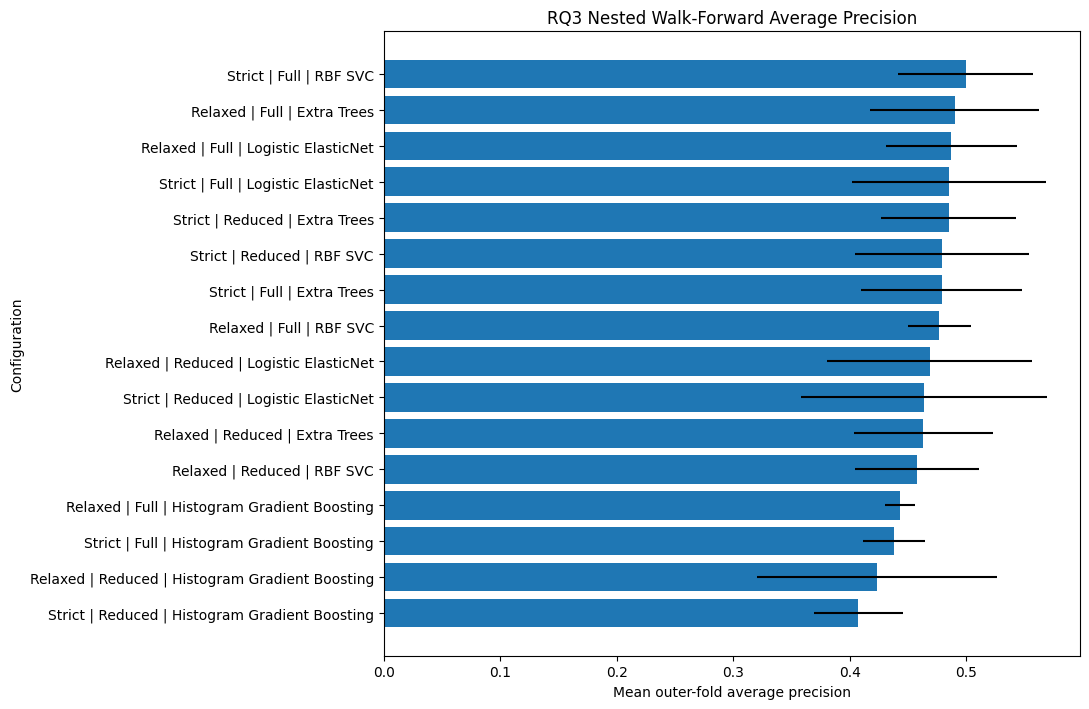

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\figures\rq3_nested_average_precision.png


In [11]:
def nested_ranking_plot(
    results: pd.DataFrame,
    metric: str,
    variability: str,
    title: str,
    xlabel: str,
    filename: str,
    higher_is_better: bool,
    top_n: int = 16,
):
    plot_data = results.copy()

    plot_data["configuration"] = (
        plot_data["dataset_variant"]
        + " | "
        + plot_data["feature_set"]
        + " | "
        + plot_data["model"]
    )

    plot_data = plot_data.sort_values(
        metric,
        ascending=not higher_is_better,
    ).head(top_n)

    plot_data = plot_data.sort_values(metric)

    fig, ax = plt.subplots(
        figsize=(11, max(6, len(plot_data) * 0.45))
    )

    ax.barh(
        plot_data["configuration"],
        plot_data[metric],
        xerr=plot_data[variability],
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Configuration")

    path = save_figure(fig, filename)
    plt.show()

    print("Saved:", path)


nested_ranking_plot(
    rq1_tuning_summary,
    metric="outer_balanced_accuracy_mean",
    variability="outer_balanced_accuracy_std",
    title="RQ1 Nested Walk-Forward Balanced Accuracy",
    xlabel="Mean outer-fold balanced accuracy",
    filename="rq1_nested_balanced_accuracy.png",
    higher_is_better=True,
)

nested_ranking_plot(
    rq2_tuning_summary,
    metric="outer_mae_bps_mean",
    variability="outer_mae_bps_std",
    title="RQ2 Nested Walk-Forward Magnitude MAE",
    xlabel="Mean outer-fold MAE in basis points (lower is better)",
    filename="rq2_nested_mae.png",
    higher_is_better=False,
)

nested_ranking_plot(
    rq3_tuning_summary,
    metric="outer_average_precision_mean",
    variability="outer_balanced_accuracy_std",
    title="RQ3 Nested Walk-Forward Average Precision",
    xlabel="Mean outer-fold average precision",
    filename="rq3_nested_average_precision.png",
    higher_is_better=True,
)

## 12. Select tuned development winners

Selection uses nested outer-fold performance only.

The selected configuration is then retuned on the full Train + Validation development period. This produces a final parameter set, but the original test period remains disabled by default.

In [12]:
rq1_winner = rq1_tuning_summary.iloc[0].to_dict()
rq2_winner = rq2_tuning_summary.iloc[0].to_dict()
rq3_winner = rq3_tuning_summary.iloc[0].to_dict()

tuned_winners = pd.DataFrame(
    [
        {
            "research_question": "RQ1 Direction",
            "dataset_variant": rq1_winner[
                "dataset_variant"
            ],
            "feature_set": rq1_winner["feature_set"],
            "model": rq1_winner["model"],
            "primary_metric": "Balanced accuracy",
            "outer_score": rq1_winner[
                "outer_balanced_accuracy_mean"
            ],
            "outer_standard_deviation": rq1_winner[
                "outer_balanced_accuracy_std"
            ],
        },
        {
            "research_question": "RQ2 Magnitude",
            "dataset_variant": rq2_winner[
                "dataset_variant"
            ],
            "feature_set": rq2_winner["feature_set"],
            "model": rq2_winner["model"],
            "primary_metric": "MAE in basis points",
            "outer_score": rq2_winner[
                "outer_mae_bps_mean"
            ],
            "outer_standard_deviation": rq2_winner[
                "outer_mae_bps_std"
            ],
        },
        {
            "research_question": "RQ3 Large Movement",
            "dataset_variant": rq3_winner[
                "dataset_variant"
            ],
            "feature_set": rq3_winner["feature_set"],
            "model": rq3_winner["model"],
            "primary_metric": "Average precision",
            "outer_score": rq3_winner[
                "outer_average_precision_mean"
            ],
            "outer_standard_deviation": np.nan,
        },
    ]
)

display(tuned_winners)

TUNED_WINNERS_PATH = (
    TABLE_ROOT
    / "nested_tuned_winners.csv"
)

tuned_winners.to_csv(
    TUNED_WINNERS_PATH,
    index=False,
)

print("Saved:", TUNED_WINNERS_PATH)

,research_question,dataset_variant,feature_set,model,primary_metric,outer_score,outer_standard_deviation
0,RQ1 Direction,Relaxed,Full,Histogram Gradient Boosting,Balanced accuracy,0.543691,0.047583
1,RQ2 Magnitude,Relaxed,Reduced,Extra Trees,MAE in basis points,13.766881,4.664372
2,RQ3 Large Movement,Strict,Full,RBF SVC,Average precision,0.499413,NaN


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\tables\nested_tuned_winners.csv


## 13. Final development-period searches

This stage derives a reproducible final parameter configuration for each research question.

It still uses only Train + Validation.

In [13]:
def final_development_search(
    winner: dict,
    task_type: str,
    target_column: str,
    scoring: str,
):
    variant_name = winner["dataset_variant"]
    feature_set_name = winner["feature_set"]
    model_name = winner["model"]

    frame = development_frame(
        datasets[variant_name]
    )

    features = FEATURE_SETS[
        feature_set_name
    ]

    X = frame[features]
    y = frame[target_column]

    if task_type == "classification":
        specification = (
            CLASSIFICATION_SEARCH_SPACES[
                model_name
            ]
        )
    elif task_type == "regression":
        specification = (
            REGRESSION_SEARCH_SPACES[
                model_name
            ]
        )
    else:
        raise ValueError(task_type)

    search = RandomizedSearchCV(
        estimator=clone(
            specification["estimator"]
        ),
        param_distributions=(
            specification["parameters"]
        ),
        n_iter=max(
            N_RANDOM_SEARCH_ITERATIONS * 2,
            12,
        ),
        scoring=scoring,
        cv=TimeSeriesSplit(
            n_splits=max(
                INNER_SPLITS + 1,
                4,
            )
        ),
        refit=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=False,
    )

    search.fit(X, y)

    return {
        "dataset_variant": variant_name,
        "feature_set": feature_set_name,
        "features": features,
        "model": model_name,
        "best_parameters": search.best_params_,
        "best_inner_score": search.best_score_,
        "estimator": search.best_estimator_,
    }


rq1_final_development = final_development_search(
    rq1_winner,
    task_type="classification",
    target_column="target_up",
    scoring="balanced_accuracy",
)

rq2_final_development = final_development_search(
    rq2_winner,
    task_type="regression",
    target_column="target_magnitude_bps",
    scoring="neg_mean_absolute_error",
)

rq3_final_development = final_development_search(
    rq3_winner,
    task_type="classification",
    target_column="target_large_move",
    scoring="average_precision",
)

final_configuration_manifest = {
    "RQ1": {
        key: value
        for key, value in rq1_final_development.items()
        if key != "estimator"
    },
    "RQ2": {
        key: value
        for key, value in rq2_final_development.items()
        if key != "estimator"
    },
    "RQ3": {
        key: value
        for key, value in rq3_final_development.items()
        if key != "estimator"
    },
    "large_move_threshold_bps": (
        LARGE_MOVE_THRESHOLD_BPS
    ),
    "outer_splits": OUTER_SPLITS,
    "inner_splits": INNER_SPLITS,
    "random_search_iterations": (
        N_RANDOM_SEARCH_ITERATIONS
    ),
    "primary_evidence": (
        "Nested expanding-window development-period performance"
    ),
    "existing_test_status": (
        "Previously viewed in baseline notebook; not fresh"
    ),
}

CONFIGURATION_PATH = (
    TUNING_ROOT
    / "final_tuned_configuration_manifest.json"
)

with open(
    CONFIGURATION_PATH,
    "w",
    encoding="utf-8",
) as configuration_file:
    json.dump(
        final_configuration_manifest,
        configuration_file,
        indent=2,
        default=str,
    )

print(
    json.dumps(
        final_configuration_manifest,
        indent=2,
        default=str,
    )
)

print("Saved:", CONFIGURATION_PATH)

{
  "RQ1": {
    "dataset_variant": "Relaxed",
    "feature_set": "Full",
    "features": [
      "ret_open_to_1500",
      "ret_last_15m",
      "ret_last_30m",
      "ret_last_60m",
      "momentum_accel_60m_vs_prior",
      "vix_level_1500",
      "vix_ret_last_15m",
      "vix_ret_last_30m",
      "vix_ret_last_60m",
      "realized_vol_30m",
      "realized_vol_60m",
      "realized_vol_120m",
      "rv_open_to_1500",
      "spy_volume_last_30m",
      "spy_volume_last_60m",
      "spy_cum_volume_to_1500",
      "spy_volume_accel_60m_vs_avg",
      "spy_dist_from_vwap_pct",
      "position_in_day_range",
      "dist_from_day_high_pct",
      "dist_from_day_low_pct",
      "atr_pct_open_to_1500"
    ],
    "model": "Histogram Gradient Boosting",
    "best_parameters": {
      "model__l2_regularization": 0.0827065762651575,
      "model__learning_rate": 0.013491814589575175,
      "model__max_bins": 128,
      "model__max_iter": 187,
      "model__max_leaf_nodes": 25,
      "model__

## 14. Optional secondary check on the existing test period

This section is deliberately disabled.

Because the baseline test metrics have already been observed, any new tuned-test result is not an independent confirmatory result. It may still be reported as a secondary sensitivity analysis, provided that limitation is stated explicitly.

In [14]:
def secondary_classification_check(
    configuration: dict,
    target_column: str,
    threshold_objective: str,
):
    variant_name = configuration[
        "dataset_variant"
    ]

    frame = datasets[variant_name].sort_values(
        "session_date"
    )

    development = frame[
        frame["data_split"].isin(
            ["Train", "Validation"]
        )
    ].reset_index(drop=True)

    test = frame[
        frame["data_split"].eq("Test")
    ].reset_index(drop=True)

    features = configuration["features"]
    estimator = configuration["estimator"]

    inner_y, inner_scores = inner_time_series_scores(
        estimator,
        development[features],
        development[target_column].astype(int),
        n_splits=max(INNER_SPLITS + 1, 4),
    )

    threshold, _ = select_threshold(
        inner_y,
        inner_scores,
        objective=threshold_objective,
    )

    estimator.fit(
        development[features],
        development[target_column].astype(int),
    )

    test_scores = model_scores(
        estimator,
        test[features],
    )

    test_predictions = (
        test_scores >= threshold
    ).astype(int)

    metrics = classification_metric_bundle(
        test[target_column].astype(int),
        test_predictions,
        test_scores,
    )

    metrics["threshold"] = threshold
    metrics["test_sessions"] = len(test)

    return metrics


def secondary_regression_check(
    configuration: dict,
):
    variant_name = configuration[
        "dataset_variant"
    ]

    frame = datasets[variant_name].sort_values(
        "session_date"
    )

    development = frame[
        frame["data_split"].isin(
            ["Train", "Validation"]
        )
    ].reset_index(drop=True)

    test = frame[
        frame["data_split"].eq("Test")
    ].reset_index(drop=True)

    features = configuration["features"]
    estimator = configuration["estimator"]

    estimator.fit(
        development[features],
        development["target_magnitude_bps"],
    )

    predictions = estimator.predict(
        test[features]
    )

    metrics = regression_metric_bundle(
        test["target_magnitude_bps"],
        predictions,
    )

    metrics["test_sessions"] = len(test)

    return metrics


if not RUN_EXISTING_TEST_AS_SECONDARY_CHECK:
    print(
        "Existing test check remains disabled. "
        "Nested development results are the primary evidence."
    )
else:
    secondary_results = {
        "RQ1": secondary_classification_check(
            rq1_final_development,
            target_column="target_up",
            threshold_objective="balanced_accuracy",
        ),
        "RQ2": secondary_regression_check(
            rq2_final_development,
        ),
        "RQ3": secondary_classification_check(
            rq3_final_development,
            target_column="target_large_move",
            threshold_objective="f1",
        ),
    }

    display(
        pd.DataFrame(
            [
                {
                    "research_question": key,
                    **value,
                }
                for key, value in (
                    secondary_results.items()
                )
            ]
        )
    )

    SECONDARY_TEST_PATH = (
        TABLE_ROOT
        / "secondary_existing_test_results.csv"
    )

    pd.DataFrame(
        [
            {
                "research_question": key,
                **value,
            }
            for key, value in (
                secondary_results.items()
            )
        ]
    ).to_csv(
        SECONDARY_TEST_PATH,
        index=False,
    )

    print("Saved:", SECONDARY_TEST_PATH)

Existing test check remains disabled. Nested development results are the primary evidence.


## 15. Dissertation-ready interpretation generator

The generated text is a structured draft rather than a substitute for final academic editing.

It explicitly distinguishes:

- prediction from ranking;
- statistical improvement from practical usefulness;
- stable results from validation-specific results;
- negative findings from failed methodology.

In [15]:
rq1_best = rq1_tuning_summary.iloc[0]
rq2_best = rq2_tuning_summary.iloc[0]
rq3_best = rq3_tuning_summary.iloc[0]

rq1_signal = (
    "limited evidence of directional predictability"
    if rq1_best["outer_balanced_accuracy_mean"] > 0.53
    else "no robust evidence of directional predictability"
)

rq2_signal = (
    "modest evidence that intraday features contain "
    "information about movement magnitude"
    if (
        rq2_best["outer_r2_mean"] > 0
        and rq2_best["outer_spearman_mean"] > 0.15
    )
    else (
        "little robust evidence that the current features "
        "predict movement magnitude"
    )
)

rq3_signal = (
    "evidence that the features can rank large-movement risk"
    if rq3_best["outer_average_precision_mean"] > 0.30
    else (
        "weak evidence that the current features rank "
        "large-movement risk"
    )
)

dissertation_draft = f"""
### RQ1: Direction of the final-hour SPX return

Nested expanding-window tuning identified the
{rq1_best['model']} model using the
{rq1_best['dataset_variant'].lower()} dataset and
{rq1_best['feature_set'].lower()} feature set as the leading
directional specification. Its mean outer-fold balanced accuracy was
{rq1_best['outer_balanced_accuracy_mean']:.3f}, with a standard
deviation of {rq1_best['outer_balanced_accuracy_std']:.3f}.
Taken together, these results provide {rq1_signal}. Any score only
slightly above 0.50 should be interpreted cautiously because the
available sample is small and the relationship varies across market
regimes.

### RQ2: Magnitude of the final-hour SPX movement

The strongest magnitude model was
{rq2_best['model']} using the
{rq2_best['dataset_variant'].lower()} dataset and
{rq2_best['feature_set'].lower()} feature set. The model achieved a
mean outer-fold MAE of {rq2_best['outer_mae_bps_mean']:.2f} basis
points, mean out-of-sample R-squared of
{rq2_best['outer_r2_mean']:.3f}, and mean Spearman correlation of
{rq2_best['outer_spearman_mean']:.3f}. This provides {rq2_signal}.
The result should be described as incremental rather than strong if
the MAE improvement is small relative to the unconditional movement
distribution.

### RQ3: Large-movement prediction and feature relevance

The leading large-movement configuration was
{rq3_best['model']} using the
{rq3_best['dataset_variant'].lower()} dataset and
{rq3_best['feature_set'].lower()} feature set. Mean outer-fold average
precision was {rq3_best['outer_average_precision_mean']:.3f}, while
mean recall after fold-specific threshold optimisation was
{rq3_best['outer_recall_mean']:.3f}. These results provide
{rq3_signal}. Feature-importance conclusions should be based on
repeated permutation importance and economic feature groups because
the input variables are correlated and individual rankings may be
unstable.

### Overall conclusion

Hyperparameter tuning can improve model fit and decision thresholds,
but it cannot create genuine information that is absent from the
features. The dissertation should therefore report both positive and
negative findings. A weak or non-significant RQ1 result remains a
valid empirical conclusion, while stronger RQ2 or RQ3 ranking results
may still justify the subsequent options-data extension.
"""

print(dissertation_draft)

DISSERTATION_DRAFT_PATH = (
    TUNING_ROOT
    / "nested_tuning_dissertation_draft.md"
)

DISSERTATION_DRAFT_PATH.write_text(
    dissertation_draft,
    encoding="utf-8",
)

print("Saved:", DISSERTATION_DRAFT_PATH)


### RQ1: Direction of the final-hour SPX return

Nested expanding-window tuning identified the
Histogram Gradient Boosting model using the
relaxed dataset and
full feature set as the leading
directional specification. Its mean outer-fold balanced accuracy was
0.544, with a standard
deviation of 0.048.
Taken together, these results provide limited evidence of directional predictability. Any score only
slightly above 0.50 should be interpreted cautiously because the
available sample is small and the relationship varies across market
regimes.

### RQ2: Magnitude of the final-hour SPX movement

The strongest magnitude model was
Extra Trees using the
relaxed dataset and
reduced feature set. The model achieved a
mean outer-fold MAE of 13.77 basis
points, mean out-of-sample R-squared of
0.062, and mean Spearman correlation of
0.444. This provides modest evidence that intraday features contain information about movement magnitude.
The result should be described as incremental rather than stro

## 16. Recommended improvements beyond tuning

Hyperparameter tuning is only one improvement. The following changes are more likely to produce a meaningful research contribution.

### More observations

Approximately two years of daily sessions is a small sample for comparing many model families. Extending the history is likely to improve reliability more than increasing model complexity.

### Options-derived information

The next phase should add genuinely new information rather than only transforming the same underlying variables:

- implied volatility;
- skew;
- term structure;
- option volume and open interest;
- put-call measures;
- gamma exposure or gamma proxies;
- strike concentration near spot;
- changes in dealer-positioning proxies.

### Better volume normalisation

Raw cumulative volume is strongly time- and regime-dependent. Develop volume-surprise variables relative to historical time-of-day profiles.

### Regime conditioning

Evaluate models separately or interact features with:

- VIX regimes;
- realised-volatility regimes;
- trend versus range-bound sessions;
- macro-event days;
- option-expiry days.

### Selective prediction

RQ1 may be more useful as a confidence-based system than as a daily classifier. Evaluate:

- accuracy when only the highest-confidence 10%, 20% or 30% of predictions are used;
- probability calibration;
- coverage-versus-accuracy curves;
- a neutral/no-trade band.

### Volatility-adjusted targets

For RQ3, compare a fixed basis-point threshold with a volatility-adjusted definition such as final-hour absolute return divided by pre-15:00 realised volatility.

### Statistical uncertainty

Use block-bootstrap confidence intervals and report fold-level dispersion. Avoid treating small metric differences as meaningful when they fall within sampling uncertainty.

### Feature-importance stability

Repeat permutation importance across outer folds and report how often each feature or feature family appears among the most important variables.

### Economic evaluation

After options are added, translate predictions into a pre-specified strategy with:

- realistic bid-ask spreads;
- slippage;
- commissions;
- fixed contract-selection rules;
- no same-bar execution assumptions;
- risk-adjusted performance and drawdown.

In [16]:
output_summary = pd.DataFrame(
    {
        "artifact": [
            "RQ1 nested tuning summary",
            "RQ1 outer-fold details",
            "RQ2 nested tuning summary",
            "RQ2 outer-fold details",
            "RQ3 nested tuning summary",
            "RQ3 outer-fold details",
            "Tuned winners",
            "Final configuration manifest",
            "Dissertation draft",
            "Figures",
        ],
        "path": [
            str(RQ1_SUMMARY_PATH),
            str(RQ1_FOLDS_PATH),
            str(RQ2_SUMMARY_PATH),
            str(RQ2_FOLDS_PATH),
            str(RQ3_SUMMARY_PATH),
            str(RQ3_FOLDS_PATH),
            str(TUNED_WINNERS_PATH),
            str(CONFIGURATION_PATH),
            str(DISSERTATION_DRAFT_PATH),
            str(FIGURE_ROOT),
        ],
    }
)

display(output_summary)

print("Hyperparameter tuning workflow completed.")
print(
    "The previously viewed test period remains disabled by default."
)

,artifact,path
0,RQ1 nested tuning summary,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
1,RQ1 outer-fold details,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
2,RQ2 nested tuning summary,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
3,RQ2 outer-fold details,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
4,RQ3 nested tuning summary,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
5,RQ3 outer-fold details,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
6,Tuned winners,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
7,Final configuration manifest,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
8,Dissertation draft,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
9,Figures,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...


Hyperparameter tuning workflow completed.
The previously viewed test period remains disabled by default.
